In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [51]:
df = pd.read_csv("C:/Users/MERIN/car_acceptability.csv")
df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5,5,med,med,good
1723,low,low,5,5,med,high,vgood
1724,low,low,5,5,big,low,unacc
1725,low,low,5,5,big,med,good


In [52]:
df.isnull()

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1722,False,False,False,False,False,False,False
1723,False,False,False,False,False,False,False
1724,False,False,False,False,False,False,False
1725,False,False,False,False,False,False,False


In [53]:
df.isnull().sum()

buying price         0
maintenance cost     0
number of doors      0
number of persons    0
lug_boot             0
safety               0
evaluation           0
dtype: int64

In [54]:
le = LabelEncoder()

df["buying price"] = le.fit_transform(df["buying price"])
df["maintenance cost"] = le.fit_transform(df["maintenance cost"])
df["lug_boot"] = le.fit_transform(df["lug_boot"])
df["safety"] = le.fit_transform(df["safety"])
df["evaluation"] = le.fit_transform(df["evaluation"])

df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,3,3,2,2,2,2,2
1,3,3,2,2,2,0,2
2,3,3,2,2,1,1,2
3,3,3,2,2,1,2,2
4,3,3,2,2,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,5,5,1,2,1
1723,1,1,5,5,1,0,3
1724,1,1,5,5,0,1,2
1725,1,1,5,5,0,2,1


In [55]:
df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,3,3,2,2,2,2,2
1,3,3,2,2,2,0,2
2,3,3,2,2,1,1,2
3,3,3,2,2,1,2,2
4,3,3,2,2,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,5,5,1,2,1
1723,1,1,5,5,1,0,3
1724,1,1,5,5,0,1,2
1725,1,1,5,5,0,2,1


In [56]:
X = df.drop("evaluation", axis=1)
Y = df["evaluation"]

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [58]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
Y_pred = rf.predict(X_test)

In [60]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.9624277456647399

Confusion Matrix:
 [[ 72   1   3   1]
 [  2  10   0   3]
 [  1   0 236   0]
 [  2   0   0  15]]


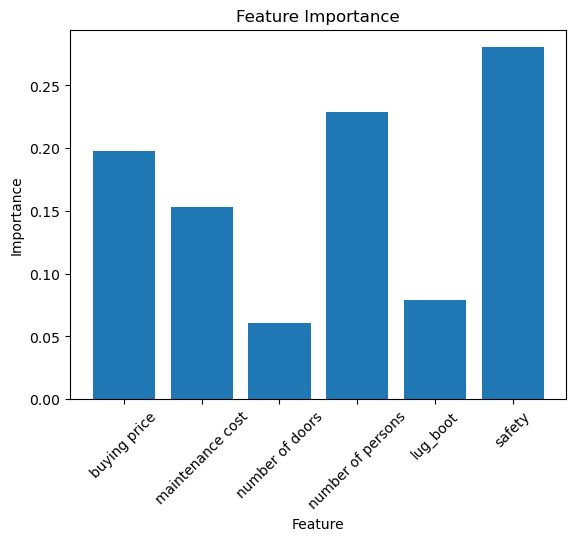

In [62]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()